# Demo: Value Iteration on a Grid World
A grid-world navigation task is a small but complete Markov decision process: a robot moves between grid cells, earns a reward for reaching a goal, and pays a penalty for wandering into hazards. This example builds the MDP tuple $(\mathcal{S},\mathcal{A},T,R,\gamma)$ for a $10\times10$ grid with one goal cell and five hazard cells, solves it with value iteration, extracts the optimal policy, and traces the resulting path.

> __Learning Objectives.__
>
> This example formulates a grid-world MDP and solves it with value iteration:
> * __Formulate a grid-world MDP:__ build the tuple $(\mathcal{S},\mathcal{A},T,R,\gamma)$ from a rectangular grid world with `build_mdp`.
> * __Run value iteration:__ apply the Bellman optimality backup to convergence in the sup-norm $\lVert\cdot\rVert_{\infty}$.
> * __Extract and visualize the policy:__ compute $\pi(s)=\arg\max_{a}Q(s,a)$ and trace the optimal path from a start state to the goal.

Let's get started.
___

## Theory
For a finite MDP $(\mathcal{S},\mathcal{A},P,R,\gamma)$ with states $s\in\mathcal{S}$, actions $a\in\mathcal{A}$, transition probabilities $P(s^{\prime}\mid s,a)$, expected immediate reward $R(s,a)$, and discount factor $\gamma\in[0,1)$, the optimal state-value function $V^{\star}:\mathcal{S}\rightarrow\mathbb{R}$ satisfies the __Bellman optimality equation__:
$$
V^{\star}(s) = \max_{a\in\mathcal{A}}\left(R(s,a) + \gamma\sum_{s^{\prime}\in\mathcal{S}} P(s^{\prime}\mid s,a)\,V^{\star}(s^{\prime})\right)\quad\forall s\in\mathcal{S}.
$$
Define the __Bellman optimality operator__ $B$ acting on any value function $V:\mathcal{S}\rightarrow\mathbb{R}$ by
$$
(BV)(s) = \max_{a\in\mathcal{A}}\left(R(s,a) + \gamma\sum_{s^{\prime}\in\mathcal{S}} P(s^{\prime}\mid s,a)\,V(s^{\prime})\right)\quad\forall s\in\mathcal{S}.
$$
__Value iteration__ starts from $V_{0}(s)=0$ for all $s\in\mathcal{S}$ and applies the operator repeatedly, $V_{k+1} = BV_{k}$, until the values stop changing. Convergence is measured with the sup-norm
$$
\lVert V_{k+1}-V_{k}\rVert_{\infty} = \max_{s\in\mathcal{S}}\lvert V_{k+1}(s)-V_{k}(s)\rvert,
$$
and the sweep stops once $\lVert V_{k+1}-V_{k}\rVert_{\infty}\le\epsilon$ for a tolerance $\epsilon>0$, or after a maximum number of iterations $T_{\max}$.

The operator $B$ is a __contraction__ in the sup-norm with modulus $\gamma$:
$$
\lVert BV - BV^{\prime}\rVert_{\infty} \le \gamma\,\lVert V - V^{\prime}\rVert_{\infty}\quad\forall V,V^{\prime}:\mathcal{S}\rightarrow\mathbb{R}.
$$
Because $\gamma<1$, the Banach fixed-point theorem guarantees a unique fixed point $V^{\star}$ and that $V_{k}\rightarrow V^{\star}$ as $k\rightarrow\infty$ from any starting $V_{0}$. Given $V^{\star}$, the action-value function is
$$
Q^{\star}(s,a) = R(s,a) + \gamma\sum_{s^{\prime}\in\mathcal{S}} P(s^{\prime}\mid s,a)\,V^{\star}(s^{\prime}),
$$
and the optimal policy is greedy with respect to it: $\pi^{\star}(s) = \arg\max_{a\in\mathcal{A}} Q^{\star}(s,a)$ for all $s\in\mathcal{S}$.
___

## Setup
This example uses functions defined in the `src` directory and a small set of external packages. The `include(...)` call below runs `Include.jl`, which activates the local project environment, loads the packages, and includes our code. The first run may take a few minutes while packages are installed and precompiled.

In [1]:
include("Include.jl");

  Activating 

project at `~/Desktop/julia_work/CHEME-140-eCornell-Repository/courses/CHEME-145/module-4`


## Build the Grid World
We build a $10\times10$ rectangular grid world with one goal cell (a charging station, reward $+100$) and five hazard cells (lava pits, reward $-100$). The `rewards::Dict{Tuple{Int,Int},Float64}` dictionary holds only these non-default cells; every other cell earns the default step reward set below. Both the goal and the hazards are __absorbing__: once the robot reaches one of these cells, the episode ends. We collect their coordinates in `absorbing::Set{Tuple{Int,Int}}` for use when we assemble the MDP. `build(MyRectangularGridWorldModel, ...)` constructs the coordinate maps and the four move vectors (left, right, down, up) that define the grid.

In [2]:
number_of_rows = 10;
number_of_cols = 10;
γ = 0.95;

rewards = Dict{Tuple{Int,Int},Float64}();
rewards[(8,8)] = 100.0;                       # charging station (goal)
for cell ∈ [(3,3), (5,5), (7,4), (2,7), (6,8)]
    rewards[cell] = -100.0;                   # lava pits (hazards)
end
absorbing = Set(keys(rewards));

world = build(MyRectangularGridWorldModel,
    (nrows = number_of_rows, ncols = number_of_cols, rewards = rewards));

## Assemble the MDP
`build_mdp` turns the grid world into the MDP tuple $(\mathcal{S},\mathcal{A},T,R,\gamma)$: the reward array `R[s,a]` gives the expected reward $R(s,a)$ for taking action $a$ from state $s$, and the transition array `T[s,s',a]` gives $P(s^{\prime}\mid s,a)$. A move onto a valid, non-absorbing cell earns that cell's reward (or `step_reward = -1.0` on an ordinary cell); a move off the grid earns `offgrid_penalty = -1000.0` and self-loops. A cell in `absorbing` earns zero reward and self-loops on every action, so its own value-to-go is $V=0$ once reached; the $+100$ (or $-100$) terminal reward is earned on the transition *into* that cell, not for occupying it.

In [3]:
mdp = build_mdp(world, γ; step_reward = -1.0, offgrid_penalty = -1000.0, absorbing = absorbing);
(length(mdp.𝒮), length(mdp.𝒜))

(100, 4)

## Run Value Iteration
We configure a `MyValueIterationModel` with a maximum of $1{,}000$ sweeps and a sup-norm tolerance $\epsilon=10^{-6}$, then call `solve(...)`, which repeatedly applies the Bellman optimality backup $V_{k+1}=BV_{k}$ until $\lVert V_{k+1}-V_{k}\rVert_{\infty}\le\epsilon$ or the iteration cap $T_{\max}=1{,}000$ is reached. The returned `solution::MyValueFunctionPolicy` stores the converged value function in the field `solution.V`.

In [4]:
solution = let
    vi = build(MyValueIterationModel, (maxiterations = 1_000, ϵ = 1e-6));
    solution = solve(vi, mdp);
    println("‖V‖∞ = ", round(maximum(abs.(solution.V)), digits = 3));
    solution
end;

‖V‖∞ = 100.0


## Extract the Policy
From $V^{\star}$ (`solution.V`) we compute the greedy policy `my_π::Vector{Int64}`, $\pi^{\star}(s)=\arg\max_{a}Q^{\star}(s,a)$, by composing `Q(...)` (the action-value function $Q^{\star}(s,a)$) and `policy(...)`.

In [5]:
my_π = policy(Q(mdp, solution.V));

## Visualize the Value Function
The heatmap below shows $V^{\star}(s)$ over the grid. Because the goal and hazard cells are absorbing and self-loop with zero reward, their own value reads $V^{\star}=0$; the $+100$ goal reward is earned on the step *into* the goal, so it is the cells immediately __adjacent__ to the goal that carry the highest values (close to $+100$), and values decay with distance from the goal and drop sharply near the hazards.

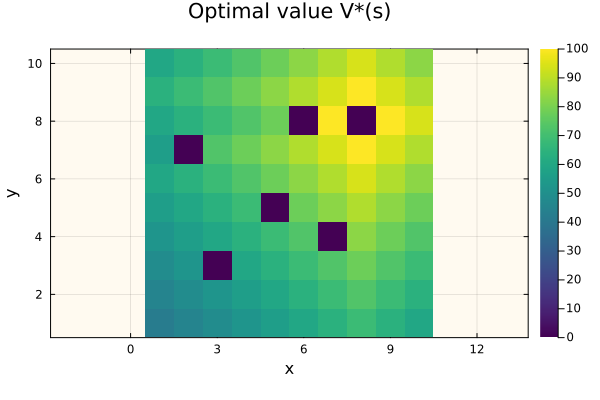

In [6]:
let
    Vgrid = [ solution.V[world.states[(x,y)]] for y ∈ 1:number_of_rows, x ∈ 1:number_of_cols ];
    heatmap(1:number_of_cols, 1:number_of_rows, Vgrid, c = :viridis, aspect_ratio = :equal,
        bg = "floralwhite", background_color_outside = "white", framestyle = :box,
        xlabel = "x", ylabel = "y", title = "Optimal value V*(s)")
end

## Visualize the Optimal Path
Starting from `(1,1)`, we trace the trajectory under the greedy policy `my_π` by repeatedly moving to $s^{\prime}$ with $a=\pi^{\star}(s)$, until the robot reaches an absorbing cell, revisits a cell, or would leave the grid. The goal is marked in teal, the hazards in red, and the start cell in orange.

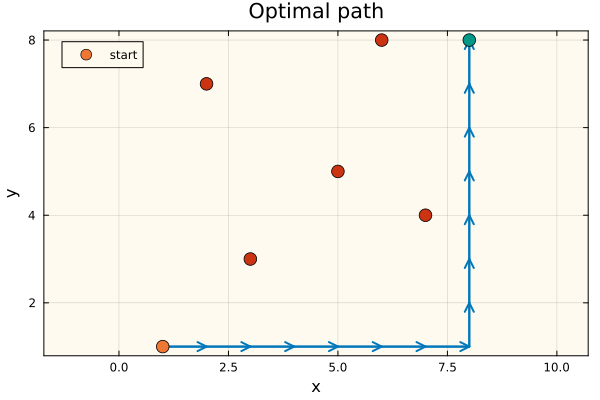

In [7]:
let
    startstate = (1,1);
    p = plot(bg = "floralwhite", background_color_outside = "white", framestyle = :box,
        aspect_ratio = :equal, xlabel = "x", ylabel = "y", title = "Optimal path");

    # draw the trajectory under π -
    s = world.states[startstate];
    visited = Set{Tuple{Int,Int}}([startstate]);
    done = false;
    while (done == false)
        current = world.coordinates[s];
        Δ = world.moves[my_π[s]];
        newpos = current .+ Δ;
        plot!([current[1], newpos[1]], [current[2], newpos[2]], label = "", arrow = true, lw = 2, c = colors[1]);
        if (in(newpos, absorbing) == true || in(newpos, visited) == true || haskey(world.states, newpos) == false)
            done = true;
        else
            s = world.states[newpos];
            push!(visited, newpos);
        end
    end

    # mark goal (green) and lava (red) -
    for (cell, r) ∈ rewards
        scatter!([cell[1]], [cell[2]], label = "", c = (r > 0 ? colors[5] : colors[4]), ms = 7);
    end
    scatter!([startstate[1]], [startstate[2]], label = "start", c = colors[3], ms = 7);
    current()
end

## Summary
This example built a $10\times10$ grid-world MDP with one goal and five hazards, solved it with value iteration, extracted the greedy policy, and traced the optimal path from a start cell to the goal.

> __Key Takeaways:__
>
> * **MDP formulation from a grid world:** `build_mdp` turns a `MyRectangularGridWorldModel` and a set of absorbing cells into the tuple $(\mathcal{S},\mathcal{A},T,R,\gamma)$, assigning rewards for the goal, the hazards, ordinary steps, and off-grid moves.
> * **Value iteration converges via a sup-norm contraction:** repeatedly applying the Bellman optimality operator, $V_{k+1}=BV_{k}$, converges to the unique fixed point $V^{\star}$ because $B$ is a contraction with modulus $\gamma$ in $\lVert\cdot\rVert_{\infty}$.
> * **The optimal policy is greedy with respect to $Q^{\star}$:** computing $Q^{\star}(s,a)$ from $V^{\star}$ and taking $\pi^{\star}(s)=\arg\max_{a}Q^{\star}(s,a)$ at every state produces a path that reaches the goal while avoiding the hazards.

Value iteration solves the Bellman optimality equation by repeated backup of the Bellman optimality operator until the value function stops changing in the sup-norm. The ungraded activity for this topic asks you to change the grid's rewards, the discount factor $\gamma$, and the tolerance $\epsilon$, and observe how the optimal value function and path respond.
___

### Additional Resources
* Bellman, R. (1957). _Dynamic Programming_. Princeton University Press.
* Sutton, R. S., & Barto, A. G. (2018). _Reinforcement Learning: An Introduction_ (2nd ed.). MIT Press.
* Kochenderfer, M. J., Wheeler, T. A., & Wray, K. H. (2022). _Algorithms for Decision Making_. MIT Press.